## Check the scrambled activities within the two cell-types: Neurons and undifferentiated cells
- compare if the regeneration of the scramble normalization logfc already worked
- check bcalm results
- check the metadata results with the normalization by scrambled
    - (threshold of 95th percentile)

In [1]:
import ast
import pandas as pd

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

### Results from BCalm counts:
- check the difference between scrambled and tested sequences within undifferentiated WTC11

In [2]:
# read the normalized counts and santiy check the scrambled counts with the labeled counts
wtc11_normalized_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_WTC11_resequencing_normalized_counts.tsv.gz"
wtc11_normalized_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/undiffWTC11_202505_80k_element_bbmap_no_outlier_removal_bc10_toptreat_results_scrambled_NP_MK_result_095_both_sided.tsv"
wtc11_normalized = pd.read_csv(wtc11_normalized_path, sep="\t")

# ngn2_normalized_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_NGN2_resequencing_SelfmadeStrandSensitive_normalized_counts.tsv.gz"
ngn2_normalized_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_element_metadata_with_bcalm_2025_04_normalized_counts_bbmap_vs_scrambled.tsv.gz"
ngn2_normalized_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/NGN2_202504_80k_element_bbmap_no_outlier_removal_bc10_toptreat_results_scrambled_NP_MK_result_095.tsv"
ngn2_normalized = pd.read_csv(ngn2_normalized_path, sep="\t", low_memory=False)


In [3]:
wtc11_normalized

,logFC,AveExpr,t,P.Value,adj.P.Val,name
0,2.309547,2.309879,57.045540,1.155602e-181,8.423989e-177,MK:AC104134.1|chr2-88538425+88538694|reference
1,0.782421,0.782424,28.945749,5.098581e-101,1.858356e-96,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...
2,0.656601,0.656562,26.207644,3.801368e-90,9.236943e-86,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...
3,0.564279,0.564305,24.718716,7.814730e-83,1.424176e-78,MK:SP2|chr17-47895875+47896144|reference
4,0.584074,0.584135,24.565689,1.775508e-81,2.588585e-77,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...
...,...,...,...,...,...,...
72892,-0.025997,-0.026009,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:PBX1|ENSG00000185630...
72893,-0.028938,-0.028954,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_CYFIP2|ENSG00000...
72894,-0.027056,-0.027062,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_SDHC|ENSG0000014...
72895,-0.026355,-0.026328,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_FOXP1|ENSG000001...


In [4]:
ngn2_normalized

,logFC,AveExpr,t,P.Value,adj.P.Val,name
0,0.702739,0.702681,45.316301,4.164022e-191,3.068343e-186,C_positive_neuron_MK:tile_37639_chr6_112501812...
1,0.599476,0.599524,42.730794,1.758116e-180,6.477516e-176,C_positive_neuron_MK:tile_37243_chr6_97306567_...
2,0.729263,0.729226,42.995945,8.230913e-177,2.021704e-172,MK:newcore_12125|chr1-52662897+52663166|reference
3,1.131702,1.131657,47.682605,3.879099e-172,7.145978e-168,MK:AC104134.1|chr2-88538425+88538694|reference
4,0.702969,0.702958,41.642342,1.751846e-171,2.581766e-167,C_positive_neuron_MK:tile_37243_chr6_97306567_...
...,...,...,...,...,...,...
73682,-0.021175,-0.021171,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF292|ENSG000001889...
73683,-0.024053,-0.024072,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF292|ENSG000001889...
73684,-0.022056,-0.022061,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF462|ENSG000001481...
73685,-0.011135,-0.011133,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF462|ENSG000001481...


load the label file

In [5]:
labelfile_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_metadata_scramble_control_label.tsv.gz" # created from: /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/qc_of_80k_mpra.ipynb
labelfile = pd.read_csv(labelfile_path, sep="\t", header=None, names=["name", "label"])
labelfile

,name,label
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,GC_Mohlke
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,GC_Mohlke
...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,GC_Glut_Chengyu
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,GC_Glut_Chengyu
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,GC_Glut_Chengyu
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,GC_Glut_Chengyu


In [6]:
# merge with label file and check if all the rows were able to be matched
ngn2_normalized_labels = ngn2_normalized.merge(labelfile, on="name", how="left")
ngn2_normalized_labels


,logFC,AveExpr,t,P.Value,adj.P.Val,name,label
0,0.702739,0.702681,45.316301,4.164022e-191,3.068343e-186,C_positive_neuron_MK:tile_37639_chr6_112501812...,C_positive_neuron_MK
1,0.599476,0.599524,42.730794,1.758116e-180,6.477516e-176,C_positive_neuron_MK:tile_37243_chr6_97306567_...,C_positive_neuron_MK
2,0.729263,0.729226,42.995945,8.230913e-177,2.021704e-172,MK:newcore_12125|chr1-52662897+52663166|reference,MK
3,1.131702,1.131657,47.682605,3.879099e-172,7.145978e-168,MK:AC104134.1|chr2-88538425+88538694|reference,MK
4,0.702969,0.702958,41.642342,1.751846e-171,2.581766e-167,C_positive_neuron_MK:tile_37243_chr6_97306567_...,C_positive_neuron_MK
...,...,...,...,...,...,...,...
73682,-0.021175,-0.021171,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF292|ENSG000001889...,cardiac_neuro_cava_random
73683,-0.024053,-0.024072,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF292|ENSG000001889...,cardiac_neuro_cava_random
73684,-0.022056,-0.022061,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,cardiac_neuro_cava_random
73685,-0.011135,-0.011133,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,cardiac_neuro_cava_random


In [7]:
ngn2_normalized_labels.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'label'], dtype='object')

In [8]:
print("Number of rows without a label (NGN2 data): ", ngn2_normalized_labels['label'].isna().sum())

Number of rows without a label (NGN2 data):  0


In [9]:
wtc11_normalized_labels = wtc11_normalized.merge(labelfile, on="name", how="left")
wtc11_normalized_labels

,logFC,AveExpr,t,P.Value,adj.P.Val,name,label
0,2.309547,2.309879,57.045540,1.155602e-181,8.423989e-177,MK:AC104134.1|chr2-88538425+88538694|reference,MK
1,0.782421,0.782424,28.945749,5.098581e-101,1.858356e-96,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,cardiac_neuro_cava_random
2,0.656601,0.656562,26.207644,3.801368e-90,9.236943e-86,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random
3,0.564279,0.564305,24.718716,7.814730e-83,1.424176e-78,MK:SP2|chr17-47895875+47896144|reference,MK
4,0.584074,0.584135,24.565689,1.775508e-81,2.588585e-77,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...
72892,-0.025997,-0.026009,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:PBX1|ENSG00000185630...,cardiac_neuro_cava_random
72893,-0.028938,-0.028954,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_CYFIP2|ENSG00000...,cardiac_neuro_cava_random
72894,-0.027056,-0.027062,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_SDHC|ENSG0000014...,cardiac_neuro_cava_random
72895,-0.026355,-0.026328,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_FOXP1|ENSG000001...,cardiac_neuro_cava_random


In [10]:
print("Number of rows without a label (wtc11 data): ", wtc11_normalized_labels['label'].isna().sum())

Number of rows without a label (wtc11 data):  0


In [11]:
wtc11_normalized_labels['label'].value_counts()


label
cardiac_neuro_cava_random            67506
MK                                    1631
C_positive_heart_AB                    636
scramble_ctrl                          485
negative_neuron_ctrl                   335
GC_Selvarajan                          327
GC_Vista                               232
C_negative_heart_MK                    202
GC_Mendelian_variants                  202
GC_Kircher                             194
GC_Cort_Chengyu                        185
C_SLEA                                 173
C_positive_neuron_MK                    93
C_positive_heart_CAD                    93
C_positive_heart_MK                     88
GC_Glut_Chengyu                         83
C_positive_neuron_NP                    75
C_positive_neuron_CD                    72
GC_DNase_positive_shuffeled             51
GC_Atrial_fib                           44
GC_DNase_positive                       38
GC_GABA_Chengyu                         36
GC_Mohlke                               34
GC_DN

In [12]:
wtc11_normalized_labels_filtered = wtc11_normalized_labels.loc[wtc11_normalized_labels['label'].isin(["cardiac_neuro_cava_random", "scramble_ctrl"])].copy()

# optional: remove the ALT containing rows of the cardiac_neuro_cava_random group
wtc11_normalized_labels_filtered = wtc11_normalized_labels_filtered.loc[(wtc11_normalized_labels_filtered['label'] != "cardiac_neuro_cava_random") | (~wtc11_normalized_labels_filtered['name'].str.contains(":ALT_"))].copy()

In [13]:
print(wtc11_normalized_labels_filtered['label'].value_counts())

label
cardiac_neuro_cava_random    25330
scramble_ctrl                  485
Name: count, dtype: int64


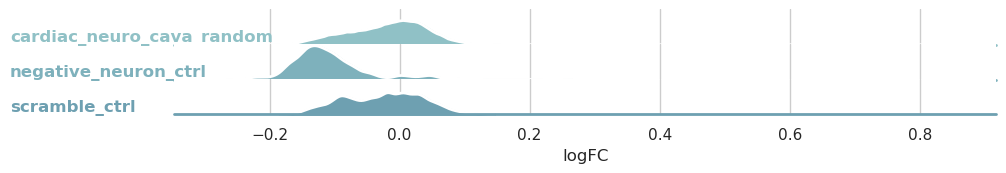

In [213]:
# plot the regions vs the scrambled controls
import seaborn as sns
import matplotlib.pyplot as plt

plot_name_col = "plot_activity_group"
plot_name_col = "label"
plot_value_col = "bcalm_element_log_ratio_activity"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_neg_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scramble_ctrl"
plot_value_col = "logFC"

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(wtc11_normalized_labels_filtered, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, plot_value_col,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.2, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, plot_value_col)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.02)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

In [146]:
wtc11_normalized_labels_filtered

,logFC,AveExpr,t,P.Value,adj.P.Val,name,label
10,0.574619,0.574748,22.647827,4.311838e-70,2.857455e-66,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,cardiac_neuro_cava_random
12,0.738756,0.738832,22.308796,2.462755e-64,1.380981e-60,cardiac_neuro_cava_random:DPYSL2|ENSG000000929...,cardiac_neuro_cava_random
20,0.402911,0.402871,18.226252,5.312250e-52,1.844034e-48,cardiac_neuro_cava_random:REF_HCN4|ENSG0000013...,cardiac_neuro_cava_random
27,0.450025,0.450033,16.783501,3.776093e-46,9.830923e-43,cardiac_neuro_cava_random:TBR1|ENSG00000136535...,cardiac_neuro_cava_random
29,0.562540,0.562568,18.116096,6.449710e-46,1.567215e-42,cardiac_neuro_cava_random:DDX3X|ENSG0000021530...,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...
72878,-0.026477,-0.026472,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_ADAM22|ENSG00000...,cardiac_neuro_cava_random
72888,-0.027167,-0.027187,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:CYFIP2|ENSG000000551...,cardiac_neuro_cava_random
72892,-0.025997,-0.026009,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:PBX1|ENSG00000185630...,cardiac_neuro_cava_random
72893,-0.028938,-0.028954,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_CYFIP2|ENSG00000...,cardiac_neuro_cava_random


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

cardiac_neuro_cava_random vs. scramble_ctrl: Mann-Whitney-Wilcoxon test two-sided, P_val:9.947e-03 U_stat=6.562e+06


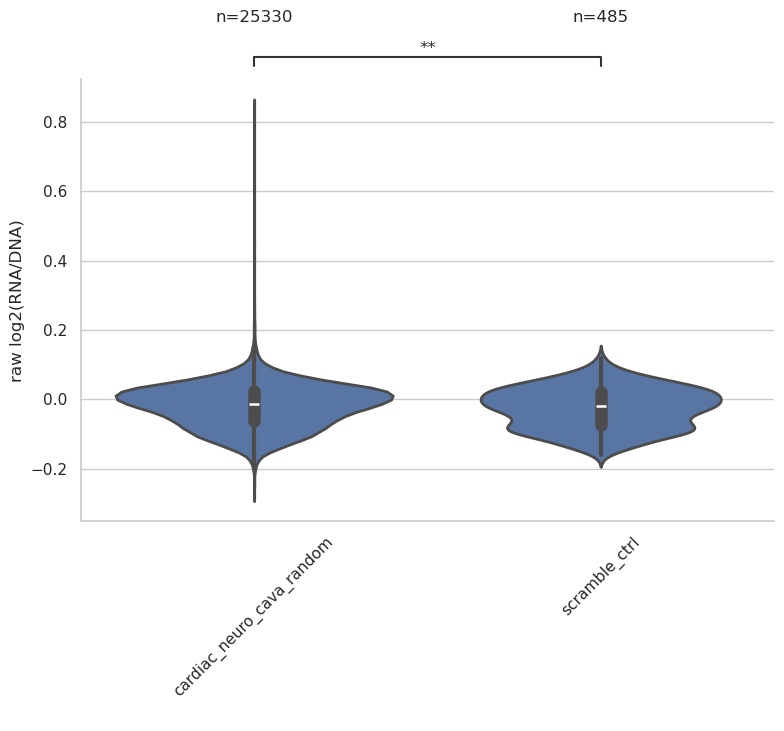

In [158]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
y_axis_col = "logFC"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=wtc11_normalized_labels_filtered, ax=ax, inner='box', linewidth=2)
# annotator = Annotator(ax, pairs, data=wtc11_normalized_labels_filtered, x=x_axis_col, y=y_axis_col, order=['liverMPRA (+)', 'liverMPRA (-)', 'DNase (+)', 'DNase (-)',  'Test cCREs'])
annotator = Annotator(ax, pairs=[('cardiac_neuro_cava_random', 'scramble_ctrl')], data=wtc11_normalized_labels_filtered, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# annotate with the number of sequences in each group
ax.text(0, 1.1, f"n={wtc11_normalized_labels_filtered['label'].value_counts()['cardiac_neuro_cava_random']}", ha='center', va='center', fontsize=12)
ax.text(1, 1.1, f"n={wtc11_normalized_labels_filtered['label'].value_counts()['scramble_ctrl']}", ha='center', va='center', fontsize=12)

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('raw log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

#### Investigate the scrambled sequences

In [24]:
wtc11_normalized_labels_filtered

,logFC,AveExpr,t,P.Value,adj.P.Val,name,label
1,0.782421,0.782424,28.945749,5.098581e-101,1.858356e-96,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,cardiac_neuro_cava_random
2,0.656601,0.656562,26.207644,3.801368e-90,9.236943e-86,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random
4,0.584074,0.584135,24.565689,1.775508e-81,2.588585e-77,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random
7,0.563274,0.563317,22.795342,1.634943e-73,1.489780e-69,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random
9,0.479235,0.479254,21.848437,2.146935e-70,1.565051e-66,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...
72892,-0.025997,-0.026009,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:PBX1|ENSG00000185630...,cardiac_neuro_cava_random
72893,-0.028938,-0.028954,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_CYFIP2|ENSG00000...,cardiac_neuro_cava_random
72894,-0.027056,-0.027062,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_SDHC|ENSG0000014...,cardiac_neuro_cava_random
72895,-0.026355,-0.026328,0.000000,1.000000e+00,1.000000e+00,cardiac_neuro_cava_random:REF_FOXP1|ENSG000001...,cardiac_neuro_cava_random


<Axes: xlabel='label', ylabel='logFC'>

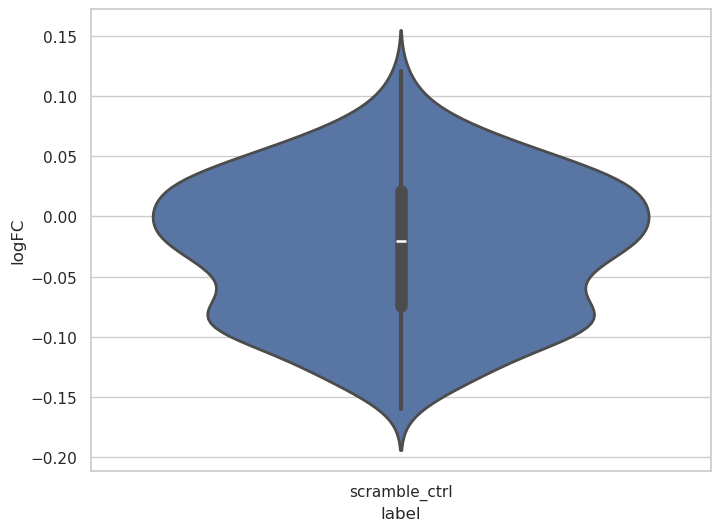

In [148]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
y_axis_col = "logFC"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot of only the scramble controls
wtc11_normalized_labels_filtered_scramble = wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == "scramble_ctrl"].copy()
sns.violinplot(x=x_axis_col, y=y_axis_col, data=wtc11_normalized_labels_filtered_scramble, ax=ax, inner='box', linewidth=2)


#### Investigate the NGN2: starting with filtering

In [14]:
# ngn2:
ngn2_normalized_labels_filtered = ngn2_normalized_labels.loc[ngn2_normalized_labels['label'].isin(["cardiac_neuro_cava_random", "scramble_ctrl", "negative_neuron_ctrl"])].copy()

# optional: remove the ALT containing rows of the cardiac_neuro_cava_random group
ngn2_normalized_labels_filtered = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] != "cardiac_neuro_cava_random") | (~ngn2_normalized_labels_filtered['name'].str.contains(":ALT_"))].copy()


In [15]:
print(ngn2_normalized_labels_filtered['label'].value_counts())

label
cardiac_neuro_cava_random    25578
scramble_ctrl                  490
negative_neuron_ctrl           341
Name: count, dtype: int64


#### For all sequences:

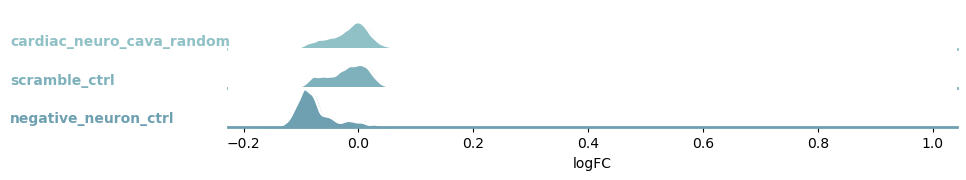

In [16]:
# plot the regions vs the scrambled controls
import seaborn as sns
import matplotlib.pyplot as plt

plot_name_col = "plot_activity_group"
plot_name_col = "label"
plot_value_col = "bcalm_element_log_ratio_activity"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_neg_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scramble_ctrl"
plot_value_col = "logFC"

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(ngn2_normalized_labels_filtered, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, plot_value_col,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.3, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, plot_value_col)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.02)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

<Axes: xlabel='label', ylabel='logFC'>

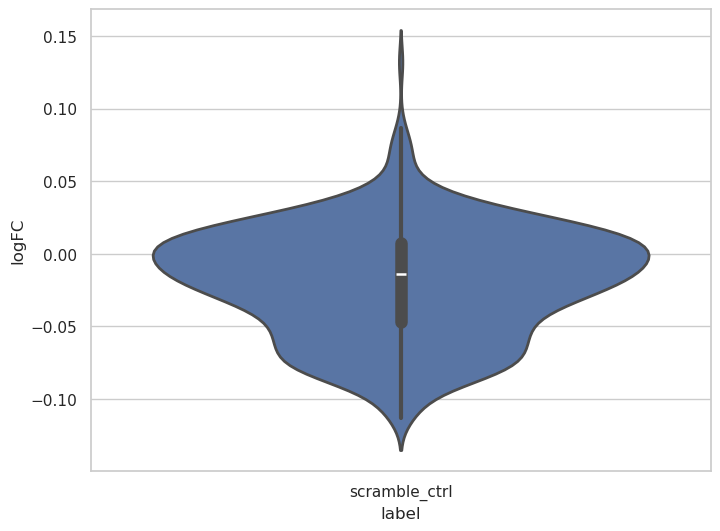

In [221]:

# plot a violin plot for each label
from statannotations.Annotator import Annotator
y_axis_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"
y_axis_col = "logFC"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot of only the scramble controls
ngn2_normalized_labels_filtered_scramble = ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == "scramble_ctrl"].copy()
sns.violinplot(x=x_axis_col, y=y_axis_col, data=ngn2_normalized_labels_filtered_scramble, ax=ax, inner='box', linewidth=2)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

cardiac_neuro_cava_random vs. scramble_ctrl: Mann-Whitney-Wilcoxon test two-sided, P_val:1.557e-02 U_stat=6.666e+06
scramble_ctrl vs. negative_neuron_ctrl: Mann-Whitney-Wilcoxon test two-sided, P_val:3.650e-68 U_stat=1.429e+05


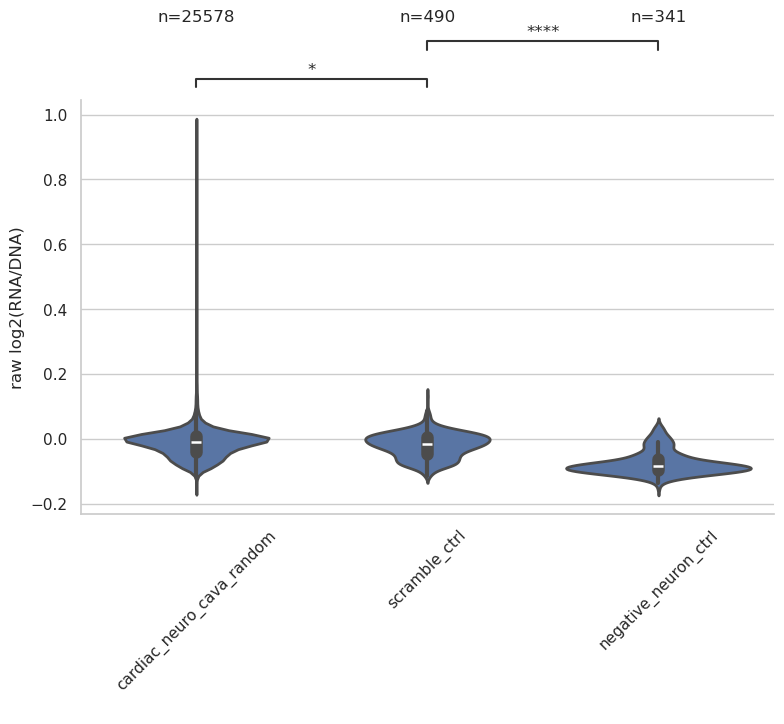

In [224]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
y_axis_col = "logFC"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=ngn2_normalized_labels_filtered, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('cardiac_neuro_cava_random', 'scramble_ctrl'), ('scramble_ctrl', 'negative_neuron_ctrl')], data=ngn2_normalized_labels_filtered, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# annotate with the number of sequences in each group
ax.text(0, 1.3, f"n={ngn2_normalized_labels_filtered['label'].value_counts()['cardiac_neuro_cava_random']}", ha='center', va='center', fontsize=12)
ax.text(1, 1.3, f"n={ngn2_normalized_labels_filtered['label'].value_counts()['scramble_ctrl']}", ha='center', va='center', fontsize=12)
ax.text(2, 1.3, f"n={ngn2_normalized_labels_filtered['label'].value_counts()['negative_neuron_ctrl']}", ha='center', va='center', fontsize=12)

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('raw log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

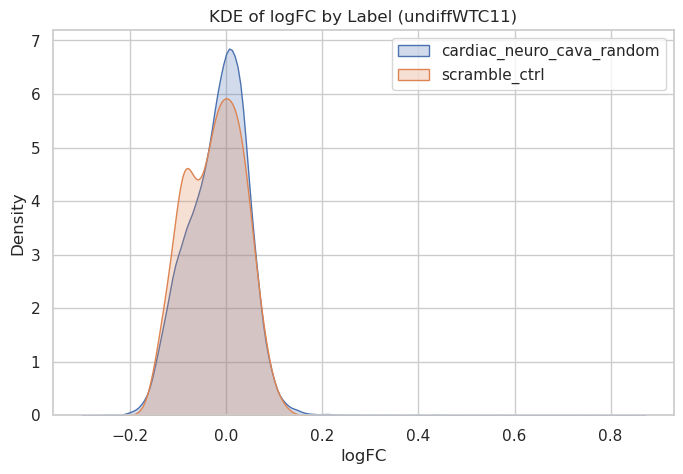

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Assume you have a DataFrame df with 'logfc' and 'label' columns

# Set plot style
sns.set(style="whitegrid")

# KDE / Density Plot with normalization
plt.figure(figsize=(8, 5))
for label in wtc11_normalized_labels_filtered['label'].unique():
    subset = wtc11_normalized_labels_filtered[wtc11_normalized_labels_filtered['label'] == label]
    sns.kdeplot(subset['logFC'], label=str(label), fill=True)
plt.title('KDE of logFC by Label (undiffWTC11)')
plt.legend()
plt.show()

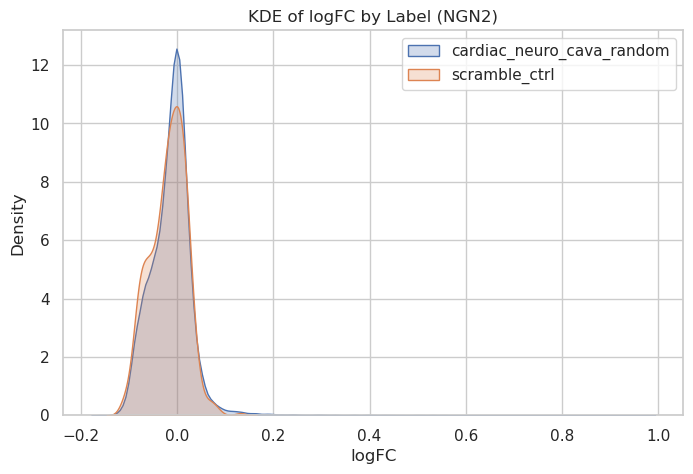

In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Assume you have a DataFrame df with 'logfc' and 'label' columns

# Set plot style
sns.set(style="whitegrid")

# KDE / Density Plot with normalization
plt.figure(figsize=(8, 5))
for label in ngn2_normalized_labels_filtered['label'].unique():
    subset = ngn2_normalized_labels_filtered[ngn2_normalized_labels_filtered['label'] == label]
    sns.kdeplot(subset['logFC'], label=str(label), fill=True)
plt.title('KDE of logFC by Label (NGN2)')
plt.legend()
plt.show()

In [162]:
# compare the two scrambled datasets
ngn2_normalized_labels_filtered_scramble['cell_type'] = 'NGN2'
wtc11_normalized_labels_filtered_scramble['cell_type'] = 'WTC11'

combined_scramble = pd.concat([wtc11_normalized_labels_filtered_scramble, ngn2_normalized_labels_filtered_scramble])
combined_scramble

,logFC,AveExpr,t,P.Value,adj.P.Val,name,label,cell_type
663,0.112279,0.112286,3.584931,0.000188,0.020611,MK:tile_1805|chr1-81262972+81263241|scramble_n...,scramble_ctrl,WTC11
839,0.120465,0.120417,3.104017,0.001079,0.093680,MK:tile_41373|chr7-42753088+42753357|scramble_...,scramble_ctrl,WTC11
1333,-0.159592,-0.159653,12.763936,0.009324,0.509511,MK:tile_8117|chr11-75072823+75073092|scramble_...,scramble_ctrl,WTC11
1398,-0.147269,-0.147273,16.319433,0.011073,0.576961,MK:tile_45312|chr9-22122918+22123187|scramble_...,scramble_ctrl,WTC11
1473,0.103750,0.103697,2.229812,0.013281,0.656827,MK:tile_17305|chr17-12487581+12487850|scramble...,scramble_ctrl,WTC11
...,...,...,...,...,...,...,...,...
71803,-0.015686,-0.015677,0.000000,1.000000,1.000000,MK:tile_42129|chr7-98613036+98613305|scramble_...,scramble_ctrl,NGN2
71804,-0.023472,-0.023474,0.000000,1.000000,1.000000,MK:tile_43865|chr8-67981809+67982078|scramble_...,scramble_ctrl,NGN2
71808,-0.013367,-0.013352,0.000000,1.000000,1.000000,MK:tile_44782|chr8-128928329+128928598|scrambl...,scramble_ctrl,NGN2
71810,-0.023575,-0.023579,0.000000,1.000000,1.000000,MK:tile_45966|chr9-88812591+88812860|scramble_...,scramble_ctrl,NGN2


In [163]:
wtc11_normalized_labels_filtered['label'].value_counts()

label
cardiac_neuro_cava_random    25330
scramble_ctrl                  485
Name: count, dtype: int64

In [ ]:
(wtc11_normalized_labels_filtered['adj.P.Val'] < 0.05).sum() # with variants: 427; only reference alleles: 130


130

In [165]:
wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random"]['logFC'].median()

-0.0121349818253901

In [166]:
ngn2_normalized_labels_filtered['label'].value_counts()

label
cardiac_neuro_cava_random    25578
scramble_ctrl                  490
Name: count, dtype: int64

In [ ]:
(ngn2_normalized_labels_filtered['adj.P.Val'] < 0.05).sum() # with variants:3779; only reference alleles: 1376

1376

In [168]:
ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random"]['logFC'].median()

-0.009743408546199199

In [ ]:
# compare the median of the sequences with positive and negative logFC (MEDIAN)
wtc11_median_pos = wtc11_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (wtc11_normalized_labels_filtered['logFC'] > 0), 'logFC'].median().round(3)
wtc11_median_neg = wtc11_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (wtc11_normalized_labels_filtered['logFC'] < 0), 'logFC'].median().round(3)

ngn2_median_pos = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (ngn2_normalized_labels_filtered['logFC'] > 0), 'logFC'].median().round(3)
ngn2_median_neg = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (ngn2_normalized_labels_filtered['logFC'] < 0), 'logFC'].median().round(3)
print(f"WTC11 median positive logFC: {wtc11_median_pos}, median negative logFC: {wtc11_median_neg}")
print(f"NGN2 median positive logFC: {ngn2_median_pos}, median negative logFC: {ngn2_median_neg}")
print(f"WTC11 scrambled median logFC: {wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].median().round(3)}")
print(f"NGN2 scrambled median logFC: {ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].median().round(3)}")

# with alternative alleles
# WTC11 median positive logFC: 0.030113977124427, median negative logFC: -0.0511963497536877
# NGN2 median positive logFC: 0.0166027932431405, median negative logFC: -0.030209267332739348
# WTC11 scrambled median positive logFC: -0.020278771436986
# NGN2 scrambled median positive logFC: -0.01421474808029285

# only reference alleles
# WTC11 median positive logFC: 0.031, median negative logFC: -0.052
# NGN2 median positive logFC: 0.016, median negative logFC: -0.03
# WTC11 scrambled median logFC: -0.02
# NGN2 scrambled median logFC: -0.014

## TAKEHOME: for WTC11 the median is now slightly higher and slightly lower; for NGN2 the median is now slightly lower for the positive group. (Suggests that the variant effects in the WTC11 groups are less frequently increasing compared to the NGN2 context)

WTC11 median positive logFC: 0.031, median negative logFC: -0.052
NGN2 median positive logFC: 0.016, median negative logFC: -0.03
WTC11 scrambled median logFC: -0.02
NGN2 scrambled median logFC: -0.014


In [ ]:
# compare the mean of the sequences with positive and negative logFC (MEAN)
wtc11_mean_pos = wtc11_normalized_labels_filtered.loc[(wtc11_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (wtc11_normalized_labels_filtered['logFC'] > 0), 'logFC'].mean().round(3)
wtc11_mean_neg = wtc11_normalized_labels_filtered.loc[(wtc11_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (wtc11_normalized_labels_filtered['logFC'] < 0), 'logFC'].mean().round(3)

ngn2_mean_pos = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (ngn2_normalized_labels_filtered['logFC'] > 0), 'logFC'].mean().round(3)
ngn2_mean_neg = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['label'] == "cardiac_neuro_cava_random") & (ngn2_normalized_labels_filtered['logFC'] < 0), 'logFC'].mean().round(3)
print(f"WTC11 mean positive logFC: {wtc11_mean_pos}, mean negative logFC: {wtc11_mean_neg}")
print(f"NGN2 mean positive logFC: {ngn2_mean_pos}, mean negative logFC: {ngn2_mean_neg}")
print(f"WTC11 scrambled mean logFC: {wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].mean().round(3)}")
print(f"NGN2 scrambled mean logFC: {ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].mean().round(3)}")


# with alternative alleles:
# WTC11 mean positive logFC: 0.039091384481204104, mean negative logFC: -0.05926500334959163
# NGN2 mean positive logFC: 0.028952989553441368, mean negative logFC: -0.03646098473580969
# WTC11 scrambled mean positive logFC: -0.025783376457857683
# NGN2 scrambled mean positive logFC: -0.01907916399116521

# only reference alleles:
# WTC11 mean positive logFC: 0.038, mean negative logFC: -0.059
# NGN2 mean positive logFC: 0.027, mean negative logFC: -0.037
# WTC11 scrambled mean logFC: -0.026
# NGN2 scrambled mean logFC: -0.019

### TAKEHOME: nearly no influence on the median (removing the variants) but has a influence on the mean as shown above

WTC11 mean positive logFC: 0.038, mean negative logFC: -0.059
NGN2 mean positive logFC: 0.027, mean negative logFC: -0.037
WTC11 scrambled mean logFC: -0.026
NGN2 scrambled mean logFC: -0.019


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WTC11 vs. NGN2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.444e-01 U_stat=1.124e+05


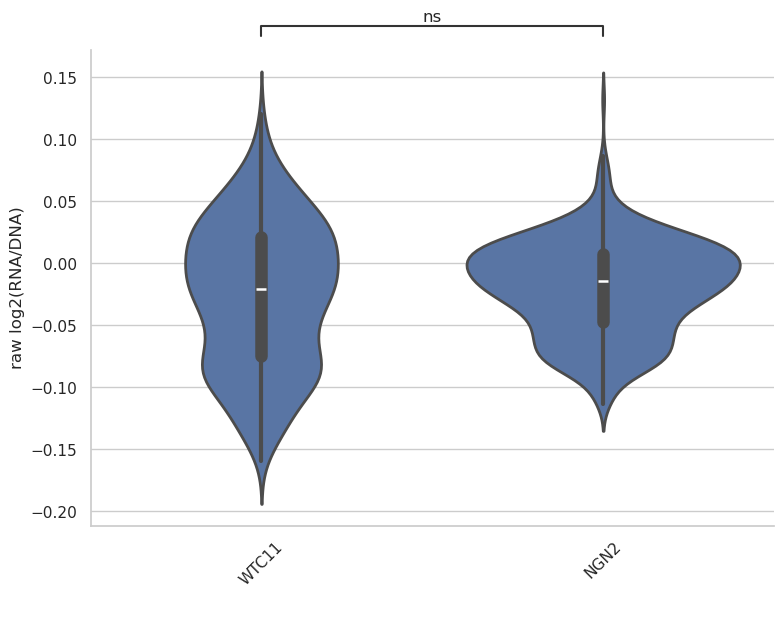

In [ ]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
y_axis_col = "logFC"
x_axis_col = "cell_type"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=combined_scramble, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('NGN2', 'WTC11')], data=combined_scramble, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('raw log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

#### Test the IQR * 1.5 to detect the sequences which are more active/less active than scrambled
- Why? with this I can check if I could detect more active sequences from the WTC11 undifferentiated data
- plot the difference to the results defined by BCalm

In [175]:
# compute the IQR of the scrambled and the threshold
wtc11_iqr = wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.75) - wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.25)
ngn2_iqr = ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.75) - ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.25)

# compute upper threshold for outliers using IQR
wtc11_upper_threshold = wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.75) + 1.5 * wtc11_iqr
ngn2_upper_threshold = ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.75) + 1.5 * ngn2_iqr

# lower threshold for outliers
wtc11_lower_threshold = wtc11_normalized_labels_filtered.loc[wtc11_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.25) - 1.5 * wtc11_iqr
ngn2_lower_threshold = ngn2_normalized_labels_filtered.loc[ngn2_normalized_labels_filtered['label'] == 'scramble_ctrl', 'logFC'].quantile(0.25) - 1.5 * ngn2_iqr

print(f"WTC11 IQR: {wtc11_iqr}, upper threshold: {wtc11_upper_threshold}, lower threshold: {wtc11_lower_threshold}")
print(f"NGN2 IQR: {ngn2_iqr}, upper threshold: {ngn2_upper_threshold}, lower threshold: {ngn2_lower_threshold}")

# add a column to the datasets to indicate if the logFC is above the threshold
wtc11_normalized_labels_filtered['more_active_iqr'] = wtc11_normalized_labels_filtered['logFC'] > wtc11_upper_threshold
ngn2_normalized_labels_filtered['more_active_iqr'] = ngn2_normalized_labels_filtered['logFC'] > ngn2_upper_threshold

wtc11_normalized_labels_filtered['less_active_iqr'] = wtc11_normalized_labels_filtered['logFC'] < wtc11_lower_threshold
ngn2_normalized_labels_filtered['less_active_iqr'] = ngn2_normalized_labels_filtered['logFC'] < ngn2_lower_threshold

# count the number of sequences that are more active than the threshold
wtc11_more_active_count = wtc11_normalized_labels_filtered['more_active_iqr'].sum()
ngn2_more_active_count = ngn2_normalized_labels_filtered['more_active_iqr'].sum()
wtc11_less_active_count = wtc11_normalized_labels_filtered['less_active_iqr'].sum()
ngn2_less_active_count = ngn2_normalized_labels_filtered['less_active_iqr'].sum()
print(f"WTC11 more active count: {wtc11_more_active_count}, less active count: {wtc11_less_active_count}")
print(f"NGN2 more active count: {ngn2_more_active_count}, less active count: {ngn2_less_active_count}")


WTC11 IQR: 0.096004178411475, upper threshold: 0.1655261151498412, lower threshold: -0.21849059849605879
NGN2 IQR: 0.05458866274311965, upper threshold: 0.08948167623965607, lower threshold: -0.12887297473282253
WTC11 more active count: 66, less active count: 8
NGN2 more active count: 403, less active count: 9


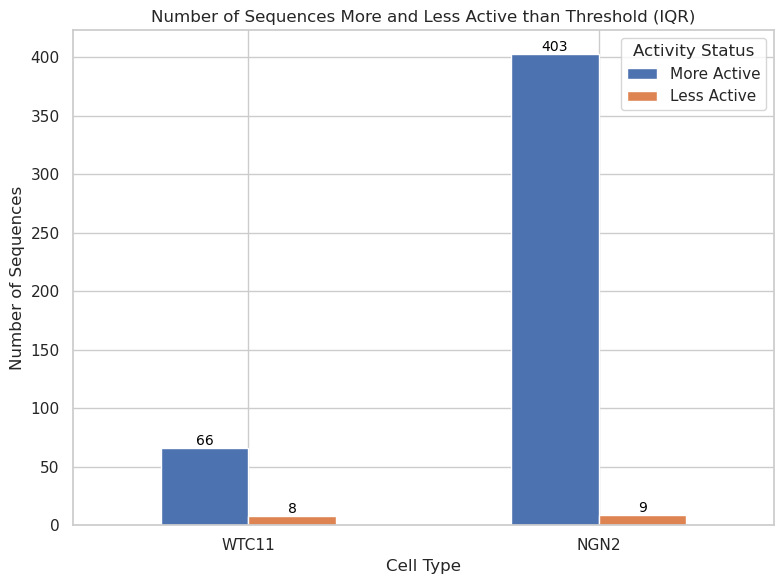

In [176]:
# plot a bar plot of the number of sequences that are more active than the threshold
import matplotlib.pyplot as plt
# Prepare data for bar plot
data = {
    'Cell Type': ['WTC11', 'NGN2'],
    'More Active': [wtc11_more_active_count, ngn2_more_active_count],
    'Less Active': [wtc11_less_active_count, ngn2_less_active_count]
}
df = pd.DataFrame(data)
# Set the index to 'Cell Type'
df.set_index('Cell Type', inplace=True)
# annotate the bars with the number of sequences
def annotate_bars(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')
# Plotting the bar plot
ax = df.plot(kind='bar', figsize=(8, 6), rot=0)
annotate_bars(ax)
plt.title('Number of Sequences More and Less Active than Threshold (IQR)')
plt.ylabel('Number of Sequences')
plt.xlabel('Cell Type')
plt.xticks(rotation=0)
plt.legend(title='Activity Status')
plt.tight_layout()
plt.show()

##### Defined by BCalm:

In [177]:
wtc11_normalized_labels_filtered.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'name', 'label',
       'more_active_iqr', 'less_active_iqr'],
      dtype='object')

WTC11 more active bcalm count: 121, less active bcalm count: 23
NGN2 more active bcalm count: 855, less active bcalm count: 720


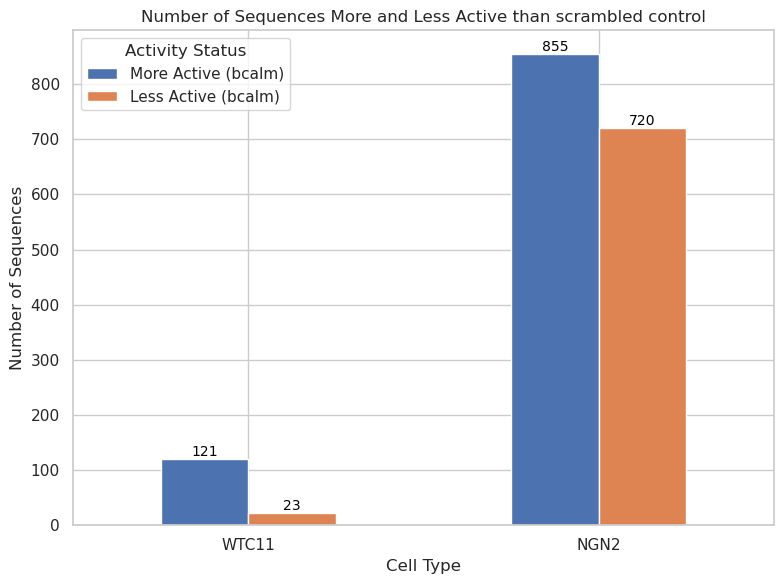

In [180]:
sig_level = 0.1
# add a column for more_active_bcalm, less_active_bcalm
wtc11_normalized_labels_filtered['more_active_bcalm'] = (wtc11_normalized_labels_filtered['adj.P.Val'] < sig_level) & (wtc11_normalized_labels_filtered['logFC'] > 0)
ngn2_normalized_labels_filtered['more_active_bcalm'] = (ngn2_normalized_labels_filtered['adj.P.Val'] < sig_level) & (ngn2_normalized_labels_filtered['logFC'] > 0)
wtc11_normalized_labels_filtered['less_active_bcalm'] = (wtc11_normalized_labels_filtered['adj.P.Val'] < sig_level) & (wtc11_normalized_labels_filtered['logFC'] < 0)
ngn2_normalized_labels_filtered['less_active_bcalm'] = (ngn2_normalized_labels_filtered['adj.P.Val'] < sig_level) & (ngn2_normalized_labels_filtered['logFC'] < 0)

# count the number of sequences that are more active than the threshold
wtc11_more_active_bcalm_count = wtc11_normalized_labels_filtered['more_active_bcalm'].sum()
ngn2_more_active_bcalm_count = ngn2_normalized_labels_filtered['more_active_bcalm'].sum()
wtc11_less_active_bcalm_count = wtc11_normalized_labels_filtered['less_active_bcalm'].sum()
ngn2_less_active_bcalm_count = ngn2_normalized_labels_filtered['less_active_bcalm'].sum()
print(f"WTC11 more active bcalm count: {wtc11_more_active_bcalm_count}, less active bcalm count: {wtc11_less_active_bcalm_count}")
print(f"NGN2 more active bcalm count: {ngn2_more_active_bcalm_count}, less active bcalm count: {ngn2_less_active_bcalm_count}")
# plot a bar plot of the number of sequences that are more active than the threshold
# Prepare data for bar plot
data_bcalm = {
    'Cell Type': ['WTC11', 'NGN2'],
    'More Active (bcalm)': [wtc11_more_active_bcalm_count, ngn2_more_active_bcalm_count],
    'Less Active (bcalm)': [wtc11_less_active_bcalm_count, ngn2_less_active_bcalm_count]
}
df_bcalm = pd.DataFrame(data_bcalm)
# Set the index to 'Cell Type'
df_bcalm.set_index('Cell Type', inplace=True)
# annotate the bars with the number of sequences
def annotate_bars(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')
# Plotting the bar plot
ax = df_bcalm.plot(kind='bar', figsize=(8, 6), rot=0)
annotate_bars(ax)
plt.title('Number of Sequences More and Less Active than scrambled control')
plt.ylabel('Number of Sequences')
plt.xlabel('Cell Type')
plt.xticks(rotation=0)
plt.legend(title='Activity Status')
plt.tight_layout()
plt.show()

In [ ]:
# plot the number of regions with no activity change for both cell-types
wtc11_no_change_count = wtc11_normalized_labels_filtered.loc[(wtc11_normalized_labels_filtered['more_active_bcalm'] == False) & (wtc11_normalized_labels_filtered['less_active_bcalm'] == False)].shape[0]
ngn2_no_change_count = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['more_active_bcalm'] == False) & (ngn2_normalized_labels_filtered['less_active_bcalm'] == False)].shape[0]

# Prepare data for bar plot
data_no_change = {
    'Cell Type': ['WTC11', 'NGN2'],
    'No Change': [wtc11_no_change_count, ngn2_no_change_count],
    'total sequences': [wtc11_normalized_labels_filtered.shape[0], ngn2_normalized_labels_filtered.shape[0]]
}
df_no_change = pd.DataFrame(data_no_change)
# Set the index to 'Cell Type'
df_no_change.set_index('Cell Type', inplace=True)
# annotate the bars with the number of sequences and the proportion compared to the total number of sequences
def annotate_bars(ax):
    for p in ax.patches:
        print(p)
        height = p.get_height()
        total = df_no_change['total sequences'].to_list()[p.get_y()]
        proportion = height / total * 100
        ax.annotate(f'{int(height)}\n({proportion:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black')

# Plotting the bar plot
ax = df_no_change.plot(kind='bar', figsize=(8, 6), rot=0)
annotate_bars(ax)

plt.title('Number of Sequences with No Activity Change')
plt.ylabel('Number of Sequences')
plt.xlabel('Cell Type')
plt.xticks(rotation=0)
plt.legend(title='Activity Status')
plt.tight_layout()
plt.show()

Rectangle(xy=(-0.25, 0), width=0.5, height=25671, angle=0)
Rectangle(xy=(0.75, 0), width=0.5, height=24493, angle=0)


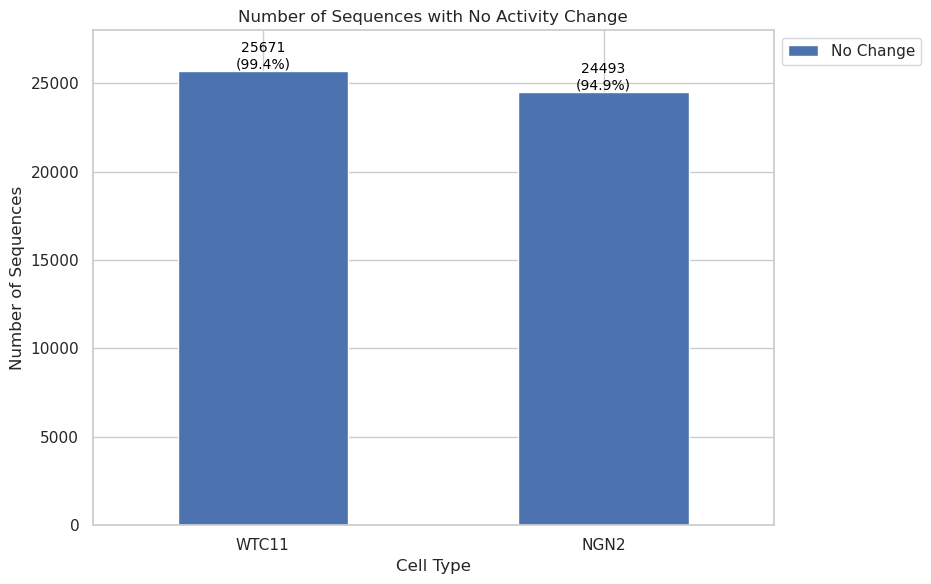

In [210]:
# plot the number of regions with no activity change for both cell-types
wtc11_no_change_count = wtc11_normalized_labels_filtered.loc[(wtc11_normalized_labels_filtered['more_active_bcalm'] == False) & (wtc11_normalized_labels_filtered['less_active_bcalm'] == False)].shape[0]
ngn2_no_change_count = ngn2_normalized_labels_filtered.loc[(ngn2_normalized_labels_filtered['more_active_bcalm'] == False) & (ngn2_normalized_labels_filtered['less_active_bcalm'] == False)].shape[0]

# Prepare data for bar plot
data_no_change = {
    'Cell Type': ['WTC11', 'NGN2'],
    'No Change': [wtc11_no_change_count, ngn2_no_change_count],
}

total_number_of_sequences = [wtc11_normalized_labels_filtered.shape[0], ngn2_normalized_labels_filtered.shape[0]]

df_no_change = pd.DataFrame(data_no_change)
# Set the index to 'Cell Type'
df_no_change.set_index('Cell Type', inplace=True)
# annotate the bars with the number of sequences and the proportion compared to the
def annotate_bars(ax):
    for p in ax.patches:
        print(p)
        height = p.get_height()
        total = total_number_of_sequences[p.get_y()]
        proportion = height / total * 100
        ax.annotate(f'{int(height)}\n({proportion:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black')

# Plotting the bar plot
ax = df_no_change.plot(kind='bar', figsize=(8, 6), rot=0)
annotate_bars(ax)

plt.ylim(0, 28000)
plt.title('Number of Sequences with No Activity Change')
plt.ylabel('Number of Sequences')
plt.xlabel('Cell Type')
plt.xticks(rotation=0)
plt.legend(title='Activity Status')
plt.tight_layout()
# legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [199]:
df_no_change

,No Change,total sequences
Cell Type,,
WTC11,25671,25815
NGN2,24493,26068


In [195]:
data_no_change

{'Cell Type': ['WTC11', 'NGN2'], 'No Change': [25671, 24493]}

### What fraction of the considered more active, less active or not active sequences are shared between the two cell types?

In [181]:
# add the cell-type specific group of the sequence to the dataframe
def get_activity_status(row):
    if row['more_active_bcalm']:
        return 'increasing_activity'
    elif row['less_active_bcalm']:
        return 'decreasing_activity'
    else:
        return 'no_change'

wtc11_normalized_labels_filtered['activity_status'] = wtc11_normalized_labels_filtered.apply(get_activity_status, axis=1)
ngn2_normalized_labels_filtered['activity_status'] = ngn2_normalized_labels_filtered.apply(get_activity_status, axis=1)
wtc11_normalized_labels_filtered['activity_status'].value_counts()
# merge the dataframes by sequence name
# if these sequences are not in both datasets, they will be dropped: because we cannot compare them
ngn2_wtc11_merged = ngn2_normalized_labels_filtered[["name", "logFC", "adj.P.Val", "activity_status"]].merge(wtc11_normalized_labels_filtered[["name", "logFC", "adj.P.Val", "activity_status"]], on='name', suffixes=('_ngn2', '_wtc11'),how="inner")
ngn2_wtc11_merged # 67,936 elements
# should we drop all ALT? => yes
ngn2_wtc11_merged_no_variants = ngn2_wtc11_merged[~ngn2_wtc11_merged['name'].str.contains("ALT")].copy()
# prepare for upset plot
ngn2_wtc11_merged_no_variants
# Define all possible states
states = ['increasing_activity_ngn2', 'decreasing_activity_ngn2', 'no_change_ngn2',
          'increasing_activity_wtc11', 'decreasing_activity_wtc11', 'no_change_wtc11']

# from the names to boolean columns for each cell-type (suffix of the column). E.g. increasing_activity_ngn2 = True if the "activity_status_ngn2" is "increasing_activity"
for state in states:
    ngn2_wtc11_merged_no_variants[state] = ngn2_wtc11_merged_no_variants.apply(
        # depending on the cell-type referred to in the given state check the corresponding activity status column and set the boolean value
        lambda row, state=state: row['activity_status_' + state.split('_')[2]] == '_'.join(state.split('_')[:-1]),
        axis=1
    )

# The simplest way to prepare for upsetplot is to create a DataFrame
# where each row is a sequence, and columns are boolean membership flags.
# Then, stack this DataFrame to get the desired MultiIndex Series.

# Select only the boolean columns for the UpSet plot
ngn2_wtc11_boolean_df = ngn2_wtc11_merged_no_variants[['name'] + states].set_index('name').copy()

# # Let's create the memberships for each sequence:
# ??? generate membership Series for UpSet plot
# memberships = []
# for idx, row in ngn2_wtc11_boolean_df.iterrows():
#     # Get the names of the columns where the value is True e.g. ('increasing_activity_ngn2', 'decreasing_activity_wtc11')
#     active_memberships = tuple(col for col, is_member in row.items() if is_member)
#     memberships.append(active_memberships)


# # generate upset plot

In [182]:
# check if each row has exactly 2 true values in each row
(ngn2_wtc11_boolean_df.sum(axis=1) != 2).sum()

0

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### Upset plot of the sequence activity groups between the two cell types


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

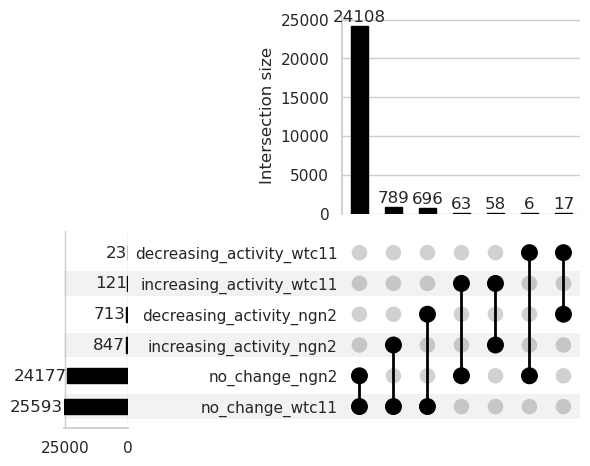

In [183]:
from upsetplot import UpSet
from upsetplot import from_indicators
sequences_by_activity_group = from_indicators(states, data=ngn2_wtc11_boolean_df).copy()

UpSet(sequences_by_activity_group, show_counts=True).plot()
plt.show()


In [ ]:
ngn2_wtc11_boolean_df['membership'] = ngn2_wtc11_boolean_df.apply(lambda row: tuple(col for col, is_member in row.items() if col in states and is_member), axis=1)
# Count the occurrences of each membership
membership_counts = ngn2_wtc11_boolean_df['membership'].value_counts()
# Convert the Series to a DataFrame
membership_counts_df = membership_counts.reset_index()
membership_counts_df.columns = ['membership', 'count']
# List of groups:
# 24108 (93%) group of sequences which have no detactable activity change in both cell-types: ('no_change_ngn2', 'no_change_wtc11'),
# 789 (3%) group of sequences which have increasing activity in NGN2 neurons but no change in WTC11 (potentially neuro specific) ('increasing_activity_ngn2', 'no_change_wtc11'),
# 696 (2.7%)group of sequences which have decreasing activity in NGN2 neurons but no change in WTC11 (potentially neuro specific) ('decreasing_activity_ngn2', 'no_change_wtc11'),
# 63 (0.24%) group of sequences which have no detactable activity change in NGN2 neurons but increasing activity in WTC11 (potentially cardiac specific) ('no_change_ngn2', 'increasing_activity_wtc11'),
# 58 (0.22%) group of sequences which have increasing activity in both cell-types ('increasing_activity_ngn2', 'increasing_activity_wtc11'),
# 17 (0.066%) group of sequences which have decreasing activity in both cell-types ('decreasing_activity_ngn2', 'decreasing_activity_wtc11'),
# 6 (0.023%) group of sequences which has no detectable activity change in NGN2 neurons but decreasing activity in WTC11 ('no_change_ngn2', 'decreasing_activity_wtc11')
# print this information automatically
for membership, count in membership_counts_df.values:
    print(f"Group {membership} has {count} sequences ({count / len(ngn2_wtc11_boolean_df) * 100:.3f}%)")


Group ('no_change_ngn2', 'no_change_wtc11') has 24108 sequences (93.671%)
Group ('increasing_activity_ngn2', 'no_change_wtc11') has 789 sequences (3.066%)
Group ('decreasing_activity_ngn2', 'no_change_wtc11') has 696 sequences (2.704%)
Group ('no_change_ngn2', 'increasing_activity_wtc11') has 63 sequences (0.245%)
Group ('increasing_activity_ngn2', 'increasing_activity_wtc11') has 58 sequences (0.225%)
Group ('decreasing_activity_ngn2', 'decreasing_activity_wtc11') has 17 sequences (0.066%)
Group ('no_change_ngn2', 'decreasing_activity_wtc11') has 6 sequences (0.023%)


In [188]:
membership_counts_df

,membership,count
0,"(no_change_ngn2, no_change_wtc11)",24108
1,"(increasing_activity_ngn2, no_change_wtc11)",789
2,"(decreasing_activity_ngn2, no_change_wtc11)",696
3,"(no_change_ngn2, increasing_activity_wtc11)",63
4,"(increasing_activity_ngn2, increasing_activity...",58
5,"(decreasing_activity_ngn2, decreasing_activity...",17
6,"(no_change_ngn2, decreasing_activity_wtc11)",6


In [189]:
ngn2_wtc11_boolean_df['membership'].value_counts(normalize=True)

membership
(no_change_ngn2, no_change_wtc11)                        0.936706
(increasing_activity_ngn2, no_change_wtc11)              0.030656
(decreasing_activity_ngn2, no_change_wtc11)              0.027043
(no_change_ngn2, increasing_activity_wtc11)              0.002448
(increasing_activity_ngn2, increasing_activity_wtc11)    0.002254
(decreasing_activity_ngn2, decreasing_activity_wtc11)    0.000661
(no_change_ngn2, decreasing_activity_wtc11)              0.000233
Name: proportion, dtype: float64

#### Focus only on the increasing decreasing groups and remove the no change groups

In [190]:
ngn2_wtc11_boolean_df

,increasing_activity_ngn2,decreasing_activity_ngn2,no_change_ngn2,increasing_activity_wtc11,decreasing_activity_wtc11,no_change_wtc11,membership
name,,,,,,,
cardiac_neuro_cava_random:REF_WWOX|ENSG00000186153.18|EH38E3192081_fwd_tile1-1,True,False,False,True,False,False,"(increasing_activity_ngn2, increasing_activity..."
cardiac_neuro_cava_random:RBM20|ENSG00000203867.8|EH38E2924690_fwd_tile1-1,True,False,False,False,False,True,"(increasing_activity_ngn2, no_change_wtc11)"
cardiac_neuro_cava_random:REF_PSMD12|ENSG00000197170.10|EH38E1880427_rev_tile1-1,True,False,False,True,False,False,"(increasing_activity_ngn2, increasing_activity..."
cardiac_neuro_cava_random:RERE|ENSG00000142599.20|EH38E1316374_rev_tile1-1,True,False,False,False,False,True,"(increasing_activity_ngn2, no_change_wtc11)"
cardiac_neuro_cava_random:TCF4|ENSG00000196628.20|EH38E1918401_rev_tile1-1,True,False,False,False,False,True,"(increasing_activity_ngn2, no_change_wtc11)"
...,...,...,...,...,...,...,...
cardiac_neuro_cava_random:ZNF292|ENSG00000188994.14|EH38E3719560_fwd_tile1-1,False,False,True,False,False,True,"(no_change_ngn2, no_change_wtc11)"
cardiac_neuro_cava_random:ZNF292|ENSG00000188994.14|EH38E3719594_fwd_tile1-1,False,False,True,False,False,True,"(no_change_ngn2, no_change_wtc11)"
cardiac_neuro_cava_random:ZNF462|ENSG00000148143.13|EH38E2715079_fwd_tile1-1,False,False,True,False,False,True,"(no_change_ngn2, no_change_wtc11)"


In [191]:
# filter the rows which are not changing expression within both cell-types
ngn2_wtc11_boolean_df_filtered = ngn2_wtc11_boolean_df.loc[ngn2_wtc11_boolean_df['membership'].isin([('increasing_activity_ngn2', 'no_change_wtc11'), ('decreasing_activity_ngn2', 'no_change_wtc11'), ('no_change_ngn2', 'increasing_activity_wtc11'), ('increasing_activity_ngn2', 'increasing_activity_wtc11'), ('decreasing_activity_ngn2', 'decreasing_activity_wtc11'), ('no_change_ngn2', 'decreasing_activity_wtc11')])].copy()

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

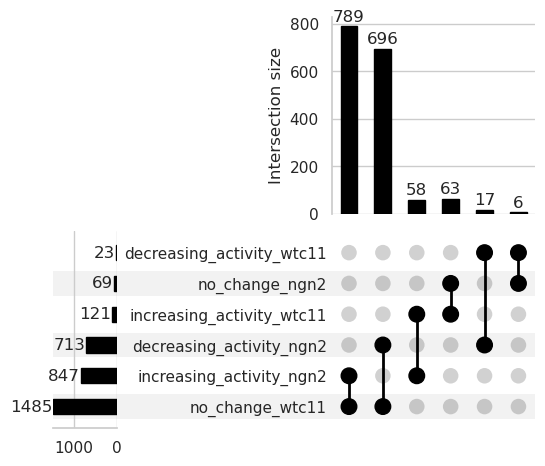

In [192]:
from upsetplot import UpSet
from upsetplot import from_indicators
filtered_sequences_by_activity_group = from_indicators(states, data=ngn2_wtc11_boolean_df_filtered).copy()

UpSet(filtered_sequences_by_activity_group, show_counts=True).plot()
plt.show()


#### Compare the correlation of the scrambled sequences between the two cell types


/tmp/ipykernel_144352/667224151.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_scramble_duplicated.sort_values(by=['name', 'cell_type'], inplace=True)


Correlation between NGN2 and WTC11 scrambled logFC values: 0.7983


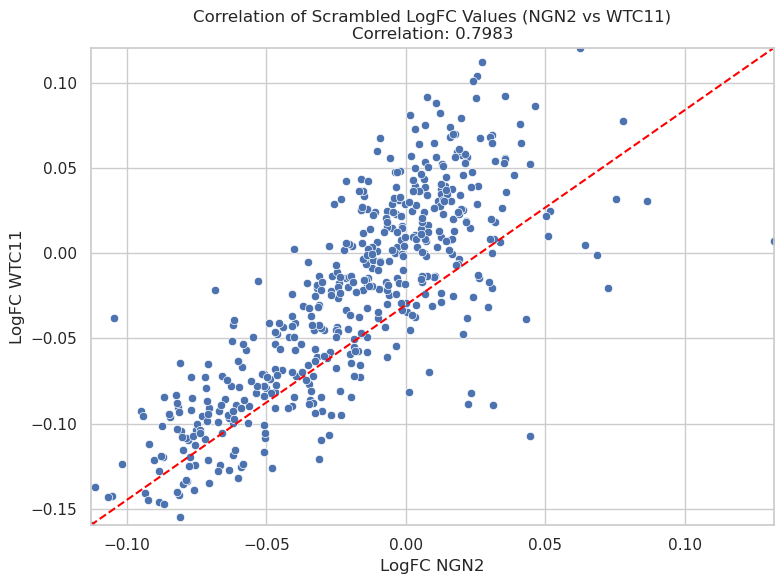

In [ ]:
# how well correlate the scrambled sequences between these two datasets (combined_scramble indicated by 'cell_type')
# keep only duplicated sequence names
combined_scramble_duplicated = combined_scramble[combined_scramble.duplicated(subset=['name'], keep=False)]
combined_scramble_duplicated.sort_values(by=['name', 'cell_type'], inplace=True)

# combine logFC values of the duplicated names
combined_scramble_duplicated_pivot = combined_scramble_duplicated.pivot(index='name', columns='cell_type', values='logFC').reset_index()
combined_scramble_duplicated_pivot
combined_scramble_duplicated_pivot.columns.name = None  # Remove the name of the columns index
# rename the columns for clarity
combined_scramble_duplicated_pivot.columns = ['name', 'logFC_NGN2', 'logFC_WTC11']
# calculate the correlation between the two logFC values
correlation = combined_scramble_duplicated_pivot[['logFC_NGN2', 'logFC_WTC11']].corr().iloc[0, 1]
print(f"Correlation between NGN2 and WTC11 scrambled logFC values: {correlation:.4f}")
# plot the correlation between the two logFC values
plt.figure(figsize=(8, 6))
sns.scatterplot(data=combined_scramble_duplicated_pivot, x='logFC_NGN2', y='logFC_WTC11')
plt.title(f'Correlation of Scrambled LogFC Values (NGN2 vs WTC11)\nCorrelation: {correlation:.4f}')
plt.xlabel('LogFC NGN2')
plt.ylabel('LogFC WTC11')
plt.plot([combined_scramble_duplicated_pivot['logFC_NGN2'].min(), combined_scramble_duplicated_pivot['logFC_NGN2'].max()],
         [combined_scramble_duplicated_pivot['logFC_WTC11'].min(), combined_scramble_duplicated_pivot['logFC_WTC11'].max()],
         color='red', linestyle='--')  # Diagonal line for reference
plt.xlim(combined_scramble_duplicated_pivot['logFC_NGN2'].min(), combined_scramble_duplicated_pivot['logFC_NGN2'].max())
plt.ylim(combined_scramble_duplicated_pivot['logFC_WTC11'].min(), combined_scramble_duplicated_pivot['logFC_WTC11'].max())
plt.tight_layout()


In [ ]:
import numpy as np

NGN2_Q1 = np.percentile(combined_scramble_duplicated_pivot['logFC_NGN2'], 25)
NGN2_Q3 = np.percentile(combined_scramble_duplicated_pivot['logFC_NGN2'], 75)
NGN2_IQR = NGN2_Q3 - NGN2_Q1

WTC11_Q1 = np.percentile(combined_scramble_duplicated_pivot['logFC_WTC11'], 25)
WTC11_Q3 = np.percentile(combined_scramble_duplicated_pivot['logFC_WTC11'], 75)
WTC11_IQR = WTC11_Q3 - WTC11_Q1

print(f"NGN2 Q1: {NGN2_Q1:.2f}, Q3: {NGN2_Q3:.2f}, IQR: {NGN2_IQR:.2f}")
print(f"WTC11 Q1: {WTC11_Q1:.2f}, Q3: {WTC11_Q3:.2f}, IQR: {WTC11_IQR:.2f}")

NGN2 Q1: -0.05, Q3: 0.01, IQR: 0.05
WTC11 Q1: -0.07, Q3: 0.02, IQR: 0.10


In [ ]:
median_ct1 = np.median(ngn2_normalized_labels_filtered['logFC'])
median_ct2 = np.median(wtc11_normalized_labels_filtered['logFC'])

print(f"Median activity in CT1: {median_ct1:.2f}")
print(f"Median activity in CT2: {median_ct2:.2f}")

if median_ct2 > median_ct1:
    print("Observation: Median activity in CT2 is higher than in CT1.")
else:
    print("Observation: Median activity in CT2 is NOT higher than in CT1 (or similar).")


NGN2_Q1 = np.percentile(ngn2_normalized_labels_filtered['logFC'], 25)
NGN2_Q3 = np.percentile(ngn2_normalized_labels_filtered['logFC'], 75)
NGN2_IQR = NGN2_Q3 - NGN2_Q1

WTC11_Q1 = np.percentile(wtc11_normalized_labels_filtered['logFC'], 25)
WTC11_Q3 = np.percentile(wtc11_normalized_labels_filtered['logFC'], 75)
WTC11_IQR = WTC11_Q3 - WTC11_Q1

print(f"NGN2 Q1: {NGN2_Q1:.2f}, Q3: {NGN2_Q3:.2f}, IQR: {NGN2_IQR:.2f}")
print(f"WTC11 Q1: {WTC11_Q1:.2f}, Q3: {WTC11_Q3:.2f}, IQR: {WTC11_IQR:.2f}")

Median activity in CT1: -0.01
Median activity in CT2: -0.01
Observation: Median activity in CT2 is NOT higher than in CT1 (or similar).
NGN2 Q1: -0.04, Q3: 0.01, IQR: 0.05
WTC11 Q1: -0.06, Q3: 0.02, IQR: 0.09


### Keep going: group the sequences within each cell-type: positive active in one, positive active in both; identify the sequences which are not active within both cell types

### Undifferentiated WTC11: activity groups
- split into activity groups and plot them (barplot)
- check enrichment for CREs
- check enrichment with open-chromatin regions

In [ ]:
import pandas as pd
import numpy as np
import yaml
import os
from importlib import reload
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [ ]:
# read metadata file with element information
# load the bcalm data for scrambled controls and create sets:


WTC11_scrambled_bcalm_path = "/home/kisa11/work/projects/80K_MPRA/classification/resources/NGN2_202501_80k_element_bbmap_outlier_removed_toptreat_results_scrambled_NP_MK_result_095.tsv"
WTC11_scrambled_bcalm_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202501_80k_element_bbmap_outlier_removed_toptreat_results_scrambled_NP_MK_result_095.tsv"
WTC11_scrambled_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
WTC11_scrambled_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
WTC11_scrambled_bcalm_name = "undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled"
WTC11_scrambled_bcalm_name = "undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled_075"
WTC11_scrambled_bcalm_path = config["files"]["creating"][WTC11_scrambled_bcalm_name]
WTC11_metadata_element_scrambled = pd.read_csv(WTC11_scrambled_bcalm_path, sep="\t", low_memory=False)
WTC11_metadata_element_scrambled
# get the element groups (more active compared to scrambled; less active compared to scramble)

output_WTC11_scrambled_cCRE = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled_095_cCRE_annotation.tsv.gz"
output_WTC11_scrambled_cCRE = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled_095_cCRE_annotation.tsv.gz"
output_WTC11_scrambled_cCRE = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled_075_cCRE_annotation.tsv.gz"

use_WTC11_CREs = True

In [ ]:
#### ADD classes to the metadata table

# get all scramble sequences (for the value normalization)
containing_scrambl = WTC11_metadata_element_scrambled.loc[WTC11_metadata_element_scrambled['name'].str.contains("scrambl")].copy()

# filter for cardiac_neuro_cava_random
WTC11_bcalm_scrambled_tested = WTC11_metadata_element_scrambled.loc[WTC11_metadata_element_scrambled['name'].str.contains("cardiac_neuro_cava_random")].copy()

adjusted_p_value_column = "adj.P.Val"
logFC_column = "logFC"
adjusted_p_value_column = "bcalm_element_adjusted_p_value"
logFC_column = "bcalm_element_log_ratio_activity"
logFC_column = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"


# get significant active group compared to scrambled
high_active = WTC11_bcalm_scrambled_tested.loc[(WTC11_bcalm_scrambled_tested[adjusted_p_value_column] < 0.1) & (WTC11_bcalm_scrambled_tested[logFC_column] > 0)].copy()
high_active_name = set(high_active['name'].to_list())

# get significantly less active group compared to scrambled
scramble_less_active = WTC11_bcalm_scrambled_tested.loc[(WTC11_bcalm_scrambled_tested[adjusted_p_value_column] < 0.1) & (WTC11_bcalm_scrambled_tested[logFC_column] <= 0)].copy()
scramble_less_active_names = set(scramble_less_active['name'].to_list())

# was für scramble ? was mit negative controls?
all_tested_names = set(WTC11_metadata_element_scrambled['name'].to_list())

# # get with no activity
no_activity_group_names = all_tested_names - scramble_less_active_names - high_active_name


In [ ]:
(WTC11_metadata_element_scrambled['bcalm_element_adjusted_p_value'] < 0.1).sum() # 0.95: 849; 0.75: 8268 # NGN2: 5722

8268

In [ ]:
# add the label to the data
# Define conditions
conditions = [
    WTC11_metadata_element_scrambled['name'].isin(high_active_name),
    WTC11_metadata_element_scrambled['name'].isin(scramble_less_active_names),
    WTC11_metadata_element_scrambled['name'].isin(no_activity_group_names)
]

# Define corresponding labels
labels = ['high_active', 'scramble_less_active', 'no_activity']

# Assign values to a new column
WTC11_metadata_element_scrambled['activity_group'] = np.select(conditions, labels, default='unknown')


activity_mapping = {
    'high_active': 2,
    'scramble_less_active': 1,
    'no_activity': 0
}

WTC11_metadata_element_scrambled['activity_group_numeric'] = WTC11_metadata_element_scrambled['activity_group'].map(activity_mapping)

WTC11_metadata_element_scrambled_bcalm = WTC11_metadata_element_scrambled.loc[WTC11_metadata_element_scrambled['bcalm_data_exists']].copy()

In [ ]:
def get_activity_group_name(activity_group):
    if activity_group == "no_activity":
        return "no significant activity"
    if activity_group == "high_active":
        return "high active"
    if activity_group == "scramble_less_active":
        return "negative regulatory activity"

def get_activity_group_name_pie_chart(activity_group):
    if activity_group == "no_activity":
        return "no significant activity"
    if activity_group == "high_active":
        return "more active than scrambled"
    if activity_group == "scramble_less_active":
        return "negative regulatory activity"

In [ ]:
WTC11_metadata_element_scrambled_bcalm["plot_activity_group"] = WTC11_metadata_element_scrambled_bcalm["activity_group"].apply(get_activity_group_name)

In [ ]:
WTC11_metadata_element_scrambled_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'activity_group', 'activity_group_numeric', 'plot_activity_group'],
      dtype='object')

In [ ]:
# WTC11_metadata_element_scrambled_bcalm['plot_activity_group'].value_counts()

In [ ]:
# # activity plotting of the grouped data:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plot_name_col = "plot_activity_group"
# plot_value_col = "bcalm_element_log_ratio_activity"
# plot_value_col = "bcalm_element_log_ratio_activity_z_score_neg_ctrl"
# plot_value_col = "bcalm_element_log_ratio_activity_z_score_scramble_ctrl"
# plot_value_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"

# # Initialize the FacetGrid object
# pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
# g = sns.FacetGrid(WTC11_metadata_element_scrambled_bcalm, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# # Draw the densities in a few steps
# g.map(sns.kdeplot, plot_value_col,
#       bw_adjust=.5, clip_on=False,
#       fill=True, alpha=1, linewidth=1.5)
# g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# # passing color=None to refline() uses the hue mapping
# g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# # Define and use a simple function to label the plot in axes coordinates
# def label(x, color, label):
#       ax = plt.gca()
#       ax.text(-0.2, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


# g.map(label, plot_value_col)

# # Set the subplots to overlap
# g.figure.subplots_adjust(hspace=-0.05)

# # Remove axes details that don't play well with overlap
# g.set_titles("")
# g.set(yticks=[], ylabel="")
# g.despine(bottom=True, left=True)
# # plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

In [ ]:
if use_WTC11_CREs:
    # compare the activity of the associated CREs
    cCREs_from_WTC11_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/WTC11_ENCFF736FHB_ENCFF857KTM_ENCFF306ZMK_cCRE_open_filtered.bed.gz"
    cCREs_from_WTC11 = pd.read_csv(cCREs_from_WTC11_path, sep="\t", header=None)
    cCREs_from_WTC11.columns = ["chr", "start", "end", "tmp_cCRE_WTC11_id", "score", "strand", "second_start", "second_end", "intensity", "annotation", "info"]
    cCREs_from_WTC11

    print("Number of open regions: ", cCREs_from_WTC11[f'tmp_cCRE_WTC11_id'].nunique())

    ccre_in_id_list = cCREs_from_WTC11['tmp_cCRE_WTC11_id'].to_list()
else:
    active_screen_ids_neuron_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/active_SCREEN_IDs_neural_progenitor_cell_ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed"
    # should be: /home/kisa/coding/80K_MPRA/cCRE_ENCODE_neural_progenitor/ENCFF221LCO_neural_progenitor_cCRE_open_filtered.bed.gz
    active_screen_ids_neuron_bed = pd.read_csv(active_screen_ids_neuron_path, sep="\t", header=None)
    active_screen_ids_neuron_bed.columns = ["chr", "start", "end", "screen_id", "score", "strand", "second_start", "second_end", "intensity", "annotation", "info"]
    active_screen_ids_neuron_bed
    ccre_in_id_list = active_screen_ids_neuron_bed['screen_id'].to_list()

Number of open regions:  41935


In [ ]:
import re

def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found

WTC11_metadata_element_scrambled_bcalm['SCREEN_ID'] = WTC11_metadata_element_scrambled_bcalm["name"].apply(extract_eh38e_number)

In [ ]:
WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'] = WTC11_metadata_element_scrambled_bcalm['SCREEN_ID'].isin(ccre_in_id_list)
# WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'].value_counts()

# tmp_cCRE_WTC11_id
# False    72268
# True       629

# NGN2
# tmp_cCRE_WTC11_id
# False    70389
# True      3298

In [ ]:
def plot_cre_group_name(open_cCRE_WTC11, cell_type="WTC11"):
    if open_cCRE_WTC11:
        return f"cCRE {cell_type}"
    else:
        return f"not cCRE {cell_type}"


In [ ]:
if use_WTC11_CREs:
    cell_type= "WTC11"
else:
    cell_type= "NPCs"
WTC11_metadata_element_scrambled_bcalm['plot_name_WTC11_cCRE'] = WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'].apply(lambda x: plot_cre_group_name(x, cell_type=cell_type))

In [ ]:
WTC11_metadata_element_scrambled_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,activity_group,activity_group_numeric,plot_activity_group,SCREEN_ID,tmp_cCRE_WTC11_id,plot_name_WTC11_cCRE
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,-0.020027,True,GC_Mohlke,0.020798,no_activity,0,no significant activity,None,False,not cCRE WTC11
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,0.023176,True,GC_Mohlke,0.741966,no_activity,0,no significant activity,None,False,not cCRE WTC11
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,0.024018,True,GC_Mohlke,0.756022,no_activity,0,no significant activity,None,False,not cCRE WTC11
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,0.008198,True,GC_Mohlke,0.491943,no_activity,0,no significant activity,None,False,not cCRE WTC11
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,-0.004509,True,GC_Mohlke,0.279841,no_activity,0,no significant activity,None,False,not cCRE WTC11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,0.046730,True,GC_Glut_Chengyu,1.135143,no_activity,0,no significant activity,None,False,not cCRE WTC11
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,0.076623,True,GC_Glut_Chengyu,1.634123,no_activity,0,no significant activity,None,False,not cCRE WTC11
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,0.101881,True,GC_Glut_Chengyu,2.055749,no_activity,0,no significant activity,None,False,not cCRE WTC11
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,0.122765,True,GC_Glut_Chengyu,2.404357,no_activity,0,no significant activity,None,False,not cCRE WTC11


In [ ]:

print("With Variants:")
WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'].value_counts()

With Variants:


tmp_cCRE_WTC11_id
False    72268
True       629
Name: count, dtype: int64

In [ ]:
WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'].value_counts(normalize=True)

tmp_cCRE_WTC11_id
False    0.991371
True     0.008629
Name: proportion, dtype: float64

In [ ]:
WTC11_metadata_element_scrambled_bcalm['plot_activity_group'].value_counts()

plot_activity_group
no significant activity         65822
high active                      3876
negative regulatory activity     3199
Name: count, dtype: int64

In [ ]:
WTC11_metadata_element_scrambled_bcalm['plot_activity_group'].value_counts(normalize=True)

plot_activity_group
no significant activity         0.902945
high active                     0.053171
negative regulatory activity    0.043884
Name: proportion, dtype: float64

In [ ]:
print("Without Variants:")

Without Variants:


In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions = WTC11_metadata_element_scrambled_bcalm.loc[~WTC11_metadata_element_scrambled_bcalm['name'].str.contains("cardiac_neuro_cava_random:ALT_")]

In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id'] = WTC11_bcalm_scrambled_bcalm_only_regions['SCREEN_ID'].isin(ccre_in_id_list)
WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id'].value_counts()

/tmp/ipykernel_8513/3818794986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id'] = WTC11_bcalm_scrambled_bcalm_only_regions['SCREEN_ID'].isin(ccre_in_id_list)


tmp_cCRE_WTC11_id
False    30554
True       167
Name: count, dtype: int64

In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id'].value_counts(normalize=True)

tmp_cCRE_WTC11_id
False    0.994564
True     0.005436
Name: proportion, dtype: float64

In [ ]:
# WTC11_bcalm_scrambled_bcalm_only_regions['label'].value_counts()

In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions['plot_activity_group'].value_counts()

plot_activity_group
no significant activity         27961
high active                      1471
negative regulatory activity     1289
Name: count, dtype: int64

In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions['plot_activity_group'].value_counts(normalize=True)

plot_activity_group
no significant activity         0.910159
high active                     0.047883
negative regulatory activity    0.041958
Name: proportion, dtype: float64

In [ ]:
asdfasdf

NameError: name 'asdfasdf' is not defined

/tmp/ipykernel_8513/24587767.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WTC11_bcalm_scrambled_bcalm_only_regions["plot_pie_chart_activity_group"] = WTC11_bcalm_scrambled_bcalm_only_regions["activity_group"].apply(get_activity_group_name_pie_chart)


Text(0.5, 1.0, 'tested cCRE activity distribution within undifferentiated WTC11 cells')

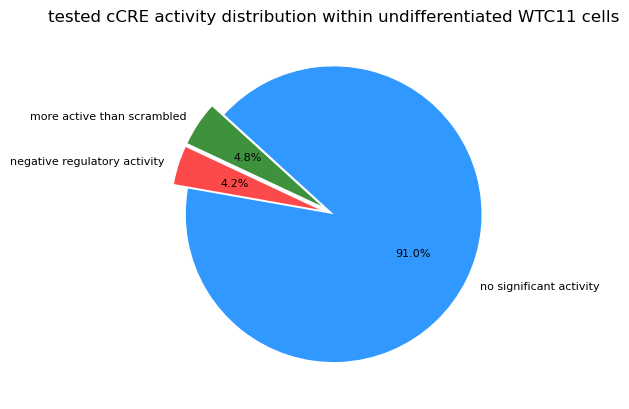

In [ ]:
def get_activity_group_name_pie_chart(activity_group):
    if activity_group == "no_activity":
        return "no significant activity"
    if activity_group == "negative_control_active":
        return "more active than negative ctrl"
    if activity_group == "high_active":
        return "more active than scrambled"
    if activity_group == "scramble_less_active":
        return "negative regulatory activity"

# Get counts
WTC11_bcalm_scrambled_bcalm_only_regions["plot_pie_chart_activity_group"] = WTC11_bcalm_scrambled_bcalm_only_regions["activity_group"].apply(get_activity_group_name_pie_chart)

counts = WTC11_bcalm_scrambled_bcalm_only_regions["plot_pie_chart_activity_group"].value_counts()

# color palette
colors = {
    "no significant activity": "#3198FF",  # Red
    "more active than scrambled": "#3E923E",  # Blue
    "negative regulatory activity": "#FC4A4A"  # red
}

explode = [0.1 if val < counts.max() else 0 for val in counts]  # Explode everything except the biggest
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=170,
    ylabel='',
    textprops={'fontsize': 8},
    explode=explode,
    colors=[colors[val] for val in counts.index],
)
plt.title("tested cCRE activity distribution within undifferentiated WTC11 cells")

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


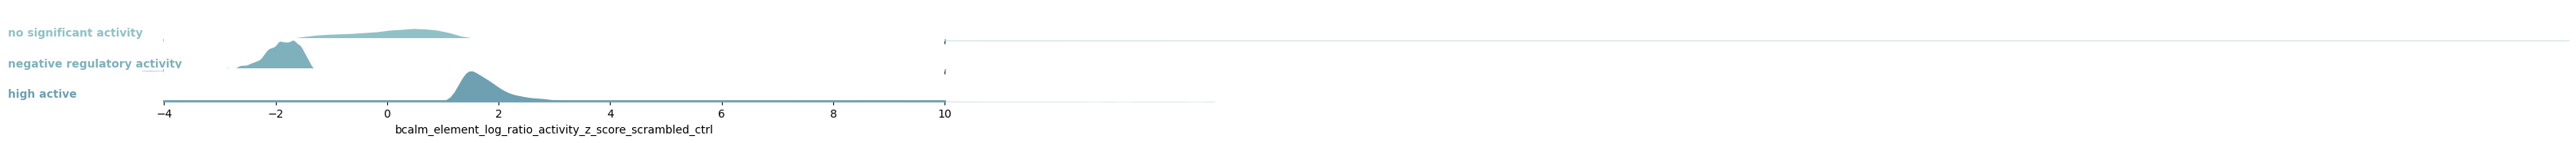

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_name_col = "plot_activity_group"
plot_value_col = "bcalm_element_log_ratio_activity"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_neg_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scramble_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(WTC11_bcalm_scrambled_bcalm_only_regions, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, plot_value_col,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# reduce x axis to 10
g.set(xlim=(-4, 10))
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.2, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, plot_value_col)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.05)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


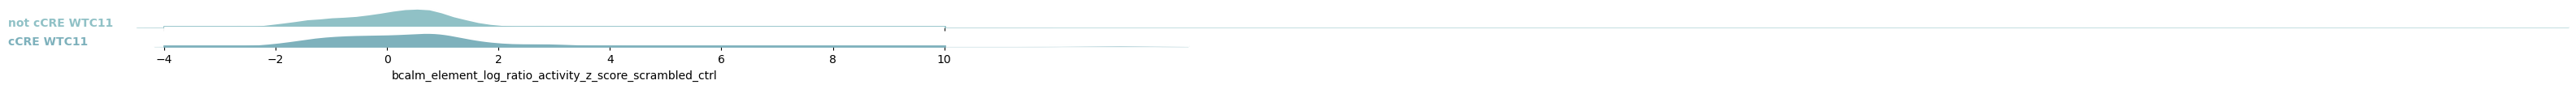

In [ ]:
# activity plotting of the grouped data:
import seaborn as sns
import matplotlib.pyplot as plt

plot_name_col = "plot_name_WTC11_cCRE"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(WTC11_bcalm_scrambled_bcalm_only_regions, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, plot_value_col,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.2, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)

# reduce x axis to 10
g.set(xlim=(-4, 10))
g.map(label, plot_value_col)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.01)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, permutation_test

print("Statistical difference between cCRE in WTC11 and the other group")

# Example: Assume element_bcalm_metadata_df_tested_elements has a boolean column 'group_A' and a numerical column 'bcalm_element_log_ratio_activity'
# cCRE_WTC11 = WTC11_bcalm_scrambled_bcalm_only_regions.loc[WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id'] == True]['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']
# not_cCRE_WTC11_overlap = WTC11_bcalm_scrambled_bcalm_only_regions.loc[WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id'] == False]['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']
cCRE_WTC11 = WTC11_metadata_element_scrambled_bcalm.loc[WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'] == True]['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']
not_cCRE_WTC11_overlap = WTC11_metadata_element_scrambled_bcalm.loc[WTC11_metadata_element_scrambled_bcalm['tmp_cCRE_WTC11_id'] == False]['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']

print("open: set size: ", cCRE_WTC11.shape[0])
print("Not open: set size: ", not_cCRE_WTC11_overlap.shape[0])


def bootstrap_ci(data1, data2, n_boot=10000):
    boot_diffs = []
    for _ in range(n_boot):
        boot1 = np.random.choice(data1, size=len(data1), replace=True)
        boot2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    return np.percentile(boot_diffs, [2.5, 97.5])


ci = bootstrap_ci(cCRE_WTC11, not_cCRE_WTC11_overlap)
print(f"Bootstrap 95% CI: {ci}")

# WTC11 only regions: Bootstrap 95% CI: [0.33536279 0.70575226]
# WTC11 with variants: [0.33265899 0.70342541]
# NGN2 neurons only regions:
# open: set size:  1194
# Not open: set size:  29830
# Bootstrap 95% CI: [-0.00389969  0.21272352]
# NGN2 with variants: [0.39619723 0.54973926]

# interpretation of the bootstrap interval
print("since the bootstrap interval does not include 0 it sugest that there is a significant difference between these two groups")

Statistical difference between cCRE in WTC11 and the other group
open: set size:  629
Not open: set size:  72268
Bootstrap 95% CI: [0.33265899 0.70342541]
since the bootstrap interval does not include 0 it sugest that there is a significant difference between these two groups


In [ ]:
WTC11_metadata_element_scrambled_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,activity_group,activity_group_numeric,plot_activity_group,SCREEN_ID,tmp_cCRE_WTC11_id,plot_name_WTC11_cCRE
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,-0.020027,True,GC_Mohlke,0.020798,no_activity,0,no significant activity,None,False,not cCRE WTC11
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,0.023176,True,GC_Mohlke,0.741966,no_activity,0,no significant activity,None,False,not cCRE WTC11
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,0.024018,True,GC_Mohlke,0.756022,no_activity,0,no significant activity,None,False,not cCRE WTC11
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,0.008198,True,GC_Mohlke,0.491943,no_activity,0,no significant activity,None,False,not cCRE WTC11
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,-0.004509,True,GC_Mohlke,0.279841,no_activity,0,no significant activity,None,False,not cCRE WTC11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,0.046730,True,GC_Glut_Chengyu,1.135143,no_activity,0,no significant activity,None,False,not cCRE WTC11
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,0.076623,True,GC_Glut_Chengyu,1.634123,no_activity,0,no significant activity,None,False,not cCRE WTC11
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,0.101881,True,GC_Glut_Chengyu,2.055749,no_activity,0,no significant activity,None,False,not cCRE WTC11
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,0.122765,True,GC_Glut_Chengyu,2.404357,no_activity,0,no significant activity,None,False,not cCRE WTC11


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

not cCRE WTC11 vs. cCRE WTC11: Mann-Whitney-Wilcoxon test two-sided, P_val:1.354e-06 U_stat=2.019e+07


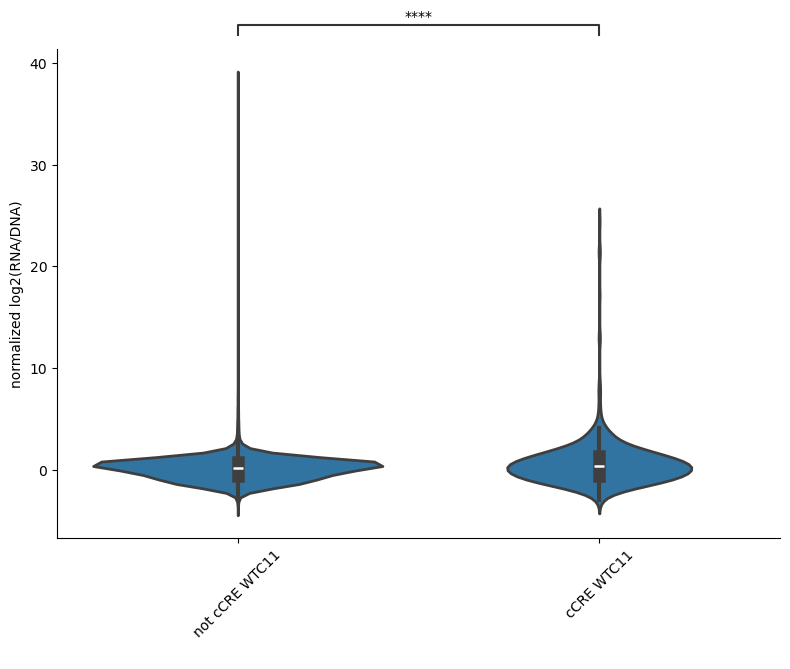

In [ ]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
y_axis_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"
x_axis_col = "plot_name_WTC11_cCRE"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
# sns.violinplot(x=x_axis_col, y=y_axis_col, data=WTC11_bcalm_scrambled_bcalm_only_regions, ax=ax, inner='box', linewidth=2)
sns.violinplot(x=x_axis_col, y=y_axis_col, data=WTC11_metadata_element_scrambled_bcalm, ax=ax, inner='box', linewidth=2)
if use_WTC11_CREs:
    # annotator = Annotator(ax, pairs=[('cCRE WTC11', 'not cCRE WTC11')], data=WTC11_bcalm_scrambled_bcalm_only_regions, x=x_axis_col, y=y_axis_col)
    annotator = Annotator(ax, pairs=[('cCRE WTC11', 'not cCRE WTC11')], data=WTC11_metadata_element_scrambled_bcalm, x=x_axis_col, y=y_axis_col)
else:
    # annotator = Annotator(ax, pairs=[(f'cCRE {cell_type}', f'not cCRE {cell_type}')], data=WTC11_bcalm_scrambled_bcalm_only_regions, x=x_axis_col, y=y_axis_col)
    annotator = Annotator(ax, pairs=[(f'cCRE {cell_type}', f'not cCRE {cell_type}')], data=WTC11_metadata_element_scrambled_bcalm, x=x_axis_col, y=y_axis_col)
    # rename x tick labels to cCRE NPC and not cCRE NPC
    ax.set_xticklabels([f'not cCRE NPC', f'cCRE NPC'])

# annotator = Annotator(ax, pairs=[('cCRE NPC', 'not cCRE NPC')], data=WTC11_bcalm_scrambled_bcalm_only_regions, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

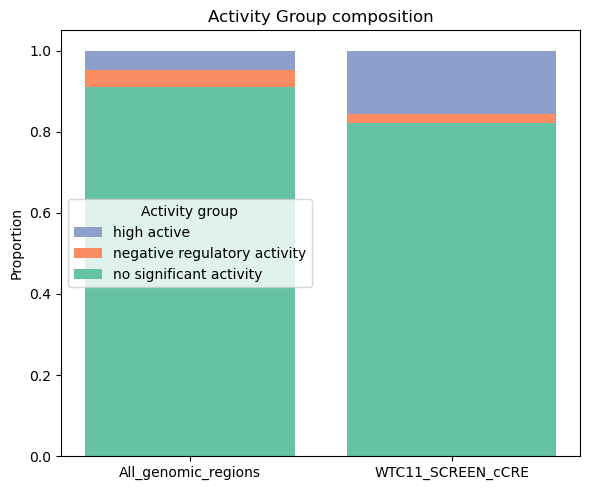

In [ ]:
# plot: with no significant elements
WTC11_bcalm_scrambled_bcalm_only_regions_CRE = WTC11_bcalm_scrambled_bcalm_only_regions.loc[WTC11_bcalm_scrambled_bcalm_only_regions['tmp_cCRE_WTC11_id']].copy()

# Compute normalized value counts
counts1 = WTC11_bcalm_scrambled_bcalm_only_regions['plot_activity_group'].value_counts(normalize=True)
# counts2 = WTC11_bcalm_scrambled_bcalm_only_regions_open_NGN2_wtc11_atac_REF['plot_activity_group'].value_counts(normalize=True)
counts2 = WTC11_bcalm_scrambled_bcalm_only_regions_CRE['plot_activity_group'].value_counts(normalize=True)

# Combine into one DataFrame
combined = pd.DataFrame({'All_genomic_regions': counts1, 'WTC11_SCREEN_cCRE': counts2}).fillna(0)



# Reorder for consistent stacking
desired_order = ['no significant activity', 'negative regulatory activity','high active']
combined = combined.reindex(desired_order)
combined
# Define a consistent color palette
group_colors = dict(zip(combined.index, sns.color_palette("Set2", n_colors=len(combined))))

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
bottoms = {'All_genomic_regions': 0, 'WTC11_SCREEN_cCRE': 0}

for group in combined.index:
    ax.bar('All_genomic_regions', combined.loc[group, 'All_genomic_regions'], bottom=bottoms['All_genomic_regions'], color=group_colors[group], label=group)
    ax.bar('WTC11_SCREEN_cCRE', combined.loc[group, 'WTC11_SCREEN_cCRE'], bottom=bottoms['WTC11_SCREEN_cCRE'], color=group_colors[group])
    bottoms['All_genomic_regions'] += combined.loc[group, 'All_genomic_regions']
    bottoms['WTC11_SCREEN_cCRE'] += combined.loc[group, 'WTC11_SCREEN_cCRE']

# # Only show one legend entry per group
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), title="Activity group")


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reverse the order
reversed_labels = list(by_label.keys())[::-1]
reversed_handles = [by_label[label] for label in reversed_labels]

ax.legend(reversed_handles,
          reversed_labels,
          title="Activity group",
          loc='center left',
          )


ax.set_ylabel("Proportion")
ax.set_title("Activity Group composition")
plt.tight_layout()
plt.show()

In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions_CRE['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'].describe()

count    167.000000
mean       0.619860
std        2.167221
min       -3.011083
25%       -0.681321
50%        0.349934
75%        1.071268
max       13.208411
Name: bcalm_element_log_ratio_activity_z_score_scrambled_ctrl, dtype: float64

In [ ]:
WTC11_bcalm_scrambled_bcalm_only_regions['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'].describe()

count    30721.000000
mean         0.127339
std          1.249161
min         -4.259698
25%         -0.657461
50%          0.190433
75%          0.820220
max         38.907176
Name: bcalm_element_log_ratio_activity_z_score_scrambled_ctrl, dtype: float64

In [ ]:
output_WTC11_scrambled_cCRE

'/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled_075_cCRE_annotation.tsv.gz'

In [ ]:
if writing_output:
    WTC11_metadata_element_scrambled_bcalm.to_csv(output_WTC11_scrambled_cCRE, sep="\t", index=False)

NameError: name 'writing_output' is not defined